#Day 32 - Deteksi Penyakit Jantung

Penyakit jantung adalah salah satu penyebab kematian terbesar di dunia.

Bayangkan kita bisa membantu dokter **menyaring pasien berisiko** hanya dari data pemeriksaan rutin.

Di notebook ini kita membangun model klasifikasi yang memprediksi apakah seorang pasien mengidap penyakit jantung atau tidak, lalu menilai performanya dengan **metrik medis** yang relevan (bukan hanya akurasi!).

> 🎯 **Tujuan Pembelajaran**

> - Melakukan EDA singkat pada data medis.
> - Melatih dua model klasifikasi: **Logistic Regression** dan **Random Forest**.
> - Memahami metrik **precision, recall, f1-score** dan kenapa *recall* penting di dunia medis.
> - Membaca **confusion matrix** dan **feature importance**.

## Tentang Dataset

Kita memakai **Heart Disease Dataset** — kumpulan data pemeriksaan jantung pasien.

- **Sumber:** [Kaggle — johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
- **Target:** kolom `target` (1 = ada penyakit jantung, 0 = sehat)

| Kolom | Arti |
|-------|------|
| `age` | Usia pasien (tahun) |
| `sex` | Jenis kelamin (1 = pria, 0 = wanita) |
| `cp` | Tipe nyeri dada (chest pain), 0–3 |
| `trestbps` | Tekanan darah istirahat (mm Hg) |
| `chol` | Kolesterol serum (mg/dl) |
| `fbs` | Gula darah puasa > 120 mg/dl (1/0) |
| `restecg` | Hasil EKG istirahat (0–2) |
| `thalach` | Detak jantung maksimum yang dicapai |
| `exang` | Angina akibat olahraga (1/0) |
| `oldpeak` | Depresi ST akibat olahraga |
| `slope` | Kemiringan segmen ST puncak |
| `ca` | Jumlah pembuluh besar (0–3) |
| `thal` | Kelainan talasemia |
| `target` | **Label**: 1 = penyakit jantung, 0 = sehat |

##Import Library

- **pandas / numpy** → olah data tabel & angka.
- **matplotlib / seaborn** → visualisasi.
- **scikit-learn** → split data, model (LogisticRegression, RandomForest), scaling, dan metrik evaluasi.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

##Import Dataset

In [35]:
!pip install kaggle
!kaggle datasets download -d johnsmith88/heart-disease-dataset
!unzip heart-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-disease-dataset.zip
replace heart.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: heart.csv               


## Eksplorasi Awal Dataset

In [36]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Interpretasi:
  - Setiap baris menginterpretasikan 1 orang pasien
  - Semua kolom sudah berupa angka
  - data bisa langsung digunakan
  - kolom `target` adalah label yang ingin di prediksi

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [38]:
df.isna().sum().sum()

np.int64(0)

In [39]:
df.duplicated().sum()

np.int64(723)

Interpretasi:

  - Data terdiri dari 1025 Baris dan 14 Kolom
  - Tidak terdapat nilai yang hilang
  - Ada beberapa baris duplikat; kita buang agar model tidak 'menghafal' baris yang sama dan agar evaluasi lebih jujur.

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


Interpretasi:
  -  Rentang nilai antar kolom sangat berbeda (mis. `chol` ratusan vs `oldpeak` < 7).
  - Perbedaan skala ini membuat **scaling** penting, terutama untuk Logistic Regression.

##Cleaning Data

In [41]:
df = df.drop_duplicates().reset_index(drop=True)

print(f'Jumlah baris duplikat setelah dihapus: {df.duplicated().sum()}')

Jumlah baris duplikat setelah dihapus: 0


In [42]:
print("Bentuk data setelah buang duplikat:", df.shape)

Bentuk data setelah buang duplikat: (302, 14)


Interpretasi:
  - Setelah duplikasi di buang, data bisa di analisa

## Eksplorasi Data Analisis

### a) Sebaran Kelas Target

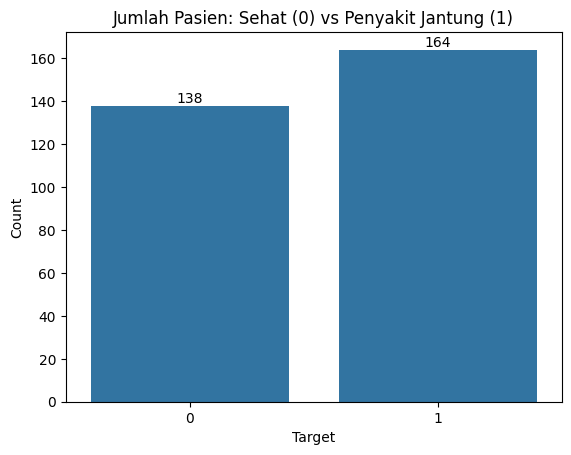

In [43]:
ax = sns.countplot(x='target', data=df)
ax.bar_label(ax.containers[0])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Jumlah Pasien: Sehat (0) vs Penyakit Jantung (1)')
plt.show()

In [44]:
df['target'].value_counts(normalize=True)*100

,proportion
target,
1,54.304636
0,45.695364


Interpretasi:

  - kedua kelas relatif balanced
  - bagus karena akurasi menjadi metrik yang tidak terlalu menyesatkan, walau kita tetap melihat recall/precision

### b) Distribusi usia berdasarkan penyakit

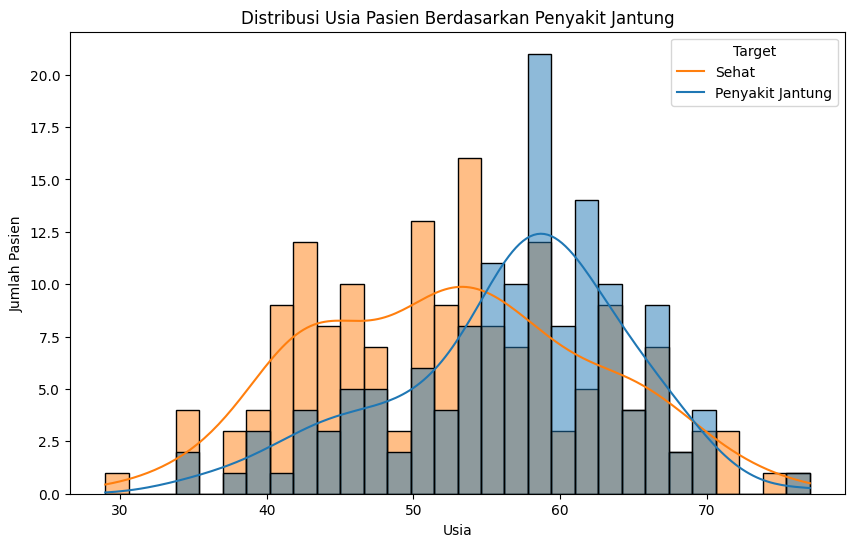

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='age', hue='target', bins=30, kde=True)

plt.xlabel('Usia')
plt.ylabel('Jumlah Pasien')
plt.title('Distribusi Usia Pasien Berdasarkan Penyakit Jantung')
plt.legend(title='Target', labels=['Sehat', 'Penyakit Jantung'])
plt.show()

Interpretasi:
  - Distribusi usia kedua kelompok tumpang tindih.
  - Jadi usia belum cukup untuk memprediksi seseorang menderita penyakit jantung
  -  Kita butuh lebih banyak kombinasi fitur fitur

### c) Heatmap Korelasi antar Fitur

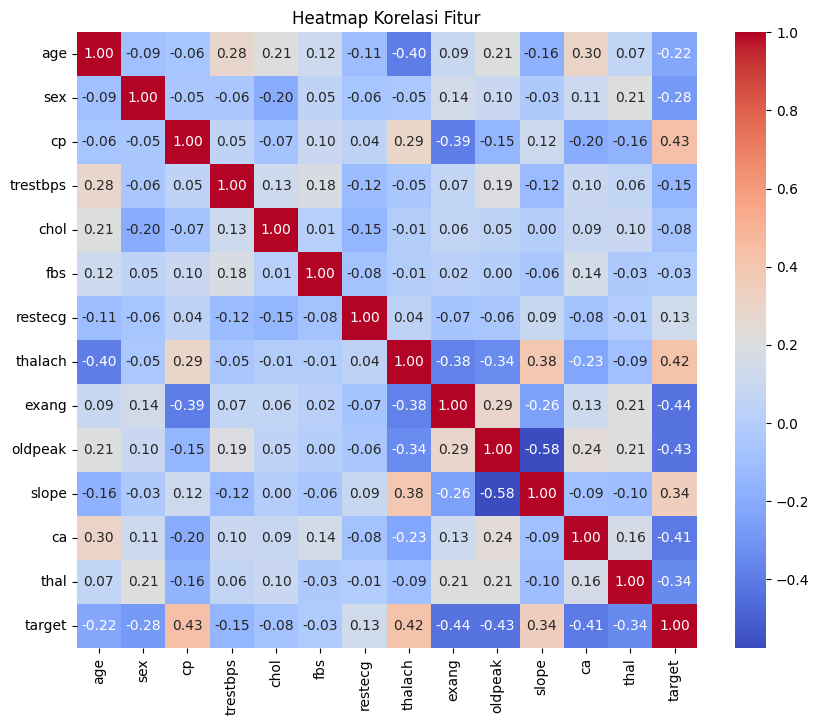

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.show()

Interpretasi:

- Korelasi Positif (+): Artinya, jika nilai suatu fitur naik, maka nilai target (kemungkinan terkena penyakit jantung) juga cenderung ikut naik. Contohnya fitur cp (nyeri dada): semakin tinggi atau parah indikasi tipe nyeri dadanya, semakin besar pula peluang pasien terdiagnosis penyakit jantung.

  
- Fitur dengan Korelasi Positif (Meningkatkan Risiko):
    - cp (0.43): Memiliki korelasi positif tertinggi kedua. Ini menunjukkan bahwa jenis nyeri dada tertentu sangat kuat kaitannya dengan indikasi positif penyakit jantung.  
    - thalach (0.42): Berkorelasi positif secara signifikan, yang menandakan pola detak jantung maksimum memiliki hubungan erat dengan status target.   
    - slope (0.34) dan age (0.22): Memiliki korelasi positif moderat, di mana peningkatan usia dan perubahan kemiringan segmen ST cenderung sejalan dengan naiknya risiko penyakit jantung.   

- Korelasi Negatif (-): Artinya, jika nilai suatu fitur naik, maka nilai target justru cenderung turun (atau sebaliknya). Contohnya fitur exang atau oldpeak: nilai fitur tersebut yang lebih tinggi justru berlawanan arah dengan status positif penyakit jantung pada model.


    
- Fitur dengan Korelasi Negatif (Menurunkan / Berlawanan dengan Risiko):
    - exang (-0.44) dan oldpeak (-0.43): Memiliki korelasi negatif yang cukup kuat dengan target.   
    - ca (-0.41) dan thal (-0.34): Menunjukkan hubungan terbalik yang kuat terhadap status penyakit jantung.   
    - sex (-0.28), trestbps (-0.15), chol (-0.08), restecg (0.13), dan fbs (-0.03): Memiliki korelasi yang relatif lemah atau mendekati nol terhadap target.

## Preprocessing Data

- Pisahkan fitur (X) dan target (y), lalu bagi menjadi data latih & uji.
- Karena Logistic Regression sensitif terhadap skala, kita lakukan **standardisasi**
- (mengubah tiap fitur agar rata-rata 0 dan standar deviasi 1).

In [47]:
#Split Fitur dengan Label
X = df.drop(columns='target')
y = df['target']

In [48]:
#Bagi data menjadi data train dan data test, dengan proporsi 80:20, gunakan random_seed dan stratify
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [49]:
#Standarisasi dan lakukan hanya pada data latih
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
#Cek data
print(f'Bentuk data latih: {X_train.shape}')
print(f'Bentuk label latih: {y_train.shape}')
print(f'Bentuk data uji: {X_test.shape}')
print(f'Bentuk label uji: {y_test.shape}')

Bentuk data latih: (241, 13)
Bentuk label latih: (241,)
Bentuk data uji: (61, 13)
Bentuk label uji: (61,)


Interpretasi:
  - `stratify=y` menjaga proporsi kelas tetap sama di data latih & uji.
  - Scaler 'belajar' hanya dari data latih (`fit_transform`) lalu diterapkan ke data uji (`transform`) agar tidak ada kebocoran informasi.

## Modeling

Kita latih dua model:
1. **Logistic Regression** — model linier sederhana, mudah ditafsirkan (pakai data ter-scaling).

2. **Random Forest** — kumpulan banyak pohon keputusan, biasanya lebih akurat (tidak butuh scaling).

### a) Logistic Regression

In [51]:
Lr = LogisticRegression(max_iter=1000,
                        random_state=42)
Lr.fit(X_train_scaled, y_train)
y_pred_lr = Lr.predict(X_test_scaled)

### b) Random Forest

In [52]:
rf = RandomForestClassifier(n_estimators=200,
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [53]:
print(f'Akurasi Logistic Regression: {accuracy_score(y_test, y_pred_lr):.2f}')
print(f'Akurasi Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}')

Akurasi Logistic Regression: 0.80
Akurasi Random Forest: 0.75


Interpretasi:
  - Kedua model memberi akurasi yang baik.
  - Random Forest umumnya unggul karena mampu menangkap pola non-linier.
  - Tapi akurasi saja belum cukup — kita lihat metrik lengkap.

## Evaluation Model

- **Precision** = dari yang diprediksi sakit, berapa yang benar sakit.
- **Recall** = dari semua yang benar sakit, berapa yang berhasil terdeteksi.

Di dunia medis, **recall pada kelas 1 (sakit)** sangat penting: kita tidak ingin melewatkan pasien yang sebenarnya sakit (false negative berbahaya).

### a) Classification Report

In [54]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["Sehat (0)", "Sakit (1)"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Sehat (0)       0.81      0.75      0.78        28
   Sakit (1)       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



Interpretasi:
  - Akurasi Keseluruhan (0.80 atau 80%): Model berhasil membuat prediksi yang tepat (baik untuk pasien sehat maupun sakit) pada 80% dari total 61 data uji.

- Kelas "Sehat" (0): Dari semua pasien yang diprediksi sehat oleh model, 81% benar (precision). Model juga berhasil mengenali 75% dari total pasien sehat yang sebenarnya ada di data uji (recall).

- Kelas "Sakit" (1): Dari semua pasien yang diprediksi sakit oleh model, 80% benar (precision). Selain itu, model mampu mendeteksi dengan baik 85% dari total pasien yang benar-benar mengidap penyakit jantung (recall).

Kesimpulan: Model ini memiliki keseimbangan yang baik, namun sedikit lebih handal dalam mendeteksi pasien yang sakit jantung (recall tertinggi di 0.85), sehingga risiko pasien sakit yang tidak terdeteksi (false negative) bisa diminimalkan.

In [55]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["Sehat (0)", "Sakit (1)"]))

=== Random Forest ===
              precision    recall  f1-score   support

   Sehat (0)       0.74      0.71      0.73        28
   Sakit (1)       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



Interpretasi:

  - Akurasi Keseluruhan (0.75 atau 75%): Model berhasil membuat prediksi yang tepat pada 75% dari total 61 data uji, yang sedikit di bawah performa model Logistic Regression sebelumnya (80%).

- Kelas "Sehat" (0): Dari semua pasien yang diprediksi sehat oleh model, 74% benar (precision), dan model berhasil mengenali 71% dari total pasien sehat yang sebenarnya ada di data uji (recall).

- Kelas "Sakit" (1): Dari semua pasien yang diprediksi sakit oleh model, 76% benar (precision), serta mampu mendeteksi 79% dari total pasien yang benar-benar sakit jantung (recall).

Kesimpulan: Meskipun Random Forest cukup seimbang, model Logistic Regression pada pengujian sebelumnya menunjukkan akurasi dan skor f1-score yang sedikit lebih unggul untuk dataset ini.

### b) Confusion Matrix kedua model

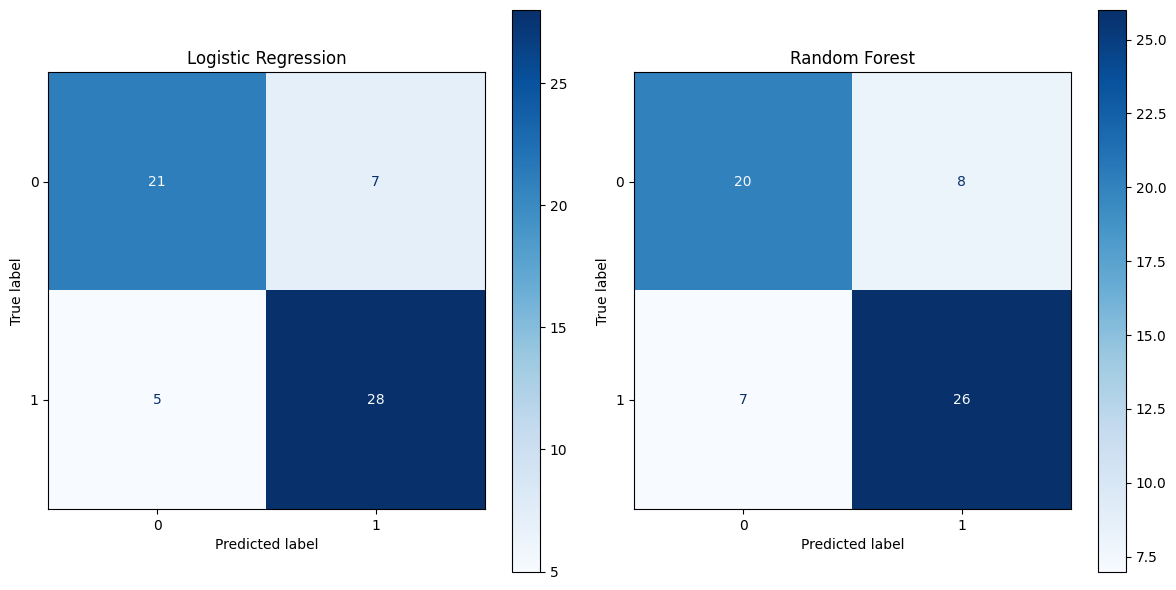

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot confusion matrix untuk Logistic Regression
ConfusionMatrixDisplay.from_estimator(Lr, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')


#plot confusion matrix untuk Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

Interpretasi:

- Logistic Regression (Kiri):
  - Berhasil menebak 21 pasien sehat (0) dan 28 pasien sakit (1) dengan tepat.   
  - Terdapat 7 pasien sehat yang keliru diprediksi sebagai sakit (False Positive), serta 5 pasien sakit yang lolos dan tidak terdeteksi oleh model (False Negative).   
  
  
- Random Forest (Kanan):
  - Berhasil menebak 20 pasien sehat (0) dan 26 pasien sakit (1) dengan tepat.   
  - Terdapat 8 pasien sehat yang keliru diprediksi sebagai sakit, serta 7 pasien sakit yang tidak terdeteksi (False Negative).   
  
  
Kesimpulan:

Logistic Regression sedikit lebih unggul karena mampu mendeteksi pasien sakit dengan lebih akurat (28 berbanding 26) dan memiliki jumlah kesalahan total (false alarm) yang lebih sedikit dibandingkan Random Forest.

### c) Feature Importance

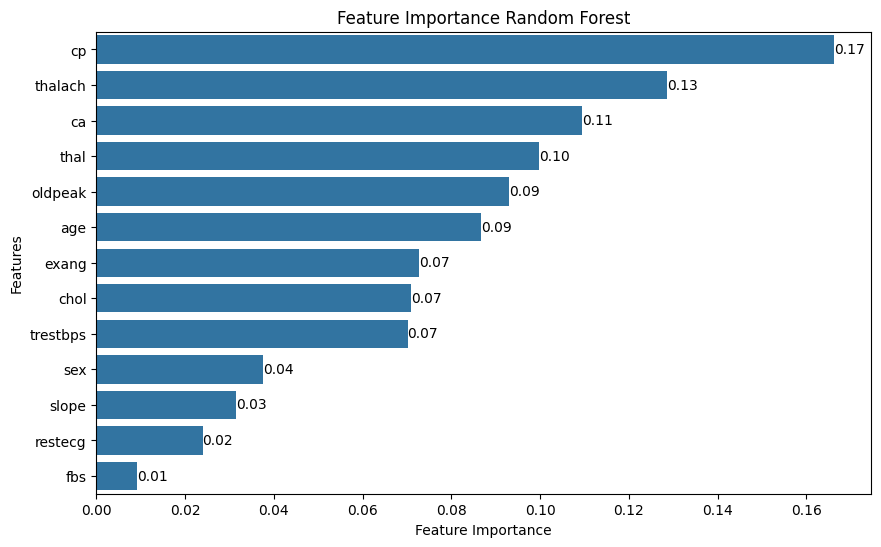

In [60]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
for i, v in enumerate(feat_imp):
    plt.text(v, i, f'{v:.2f}', ha='left', va='center')
plt.title('Feature Importance Random Forest')
plt.show()

Interpretasi:

- Faktor Paling Berpengaruh (Top 3):
  - cp (0.17 atau 17%), thalach (0.13 atau 13%), dan ca (0.11 atau 11%) adalah tiga fitur yang paling diandalkan oleh model dalam mendeteksi kondisi jantung pasien. Jenis nyeri dada (cp) memegang porsi terbesar sebagai penentu utama.   

- Faktor Pendukung Menengah:
  - Variabel seperti thal (0.10), oldpeak (0.09), dan age (0.09) juga memberikan kontribusi yang cukup tinggi bagi keputusan model.

- Faktor Pengaruh Kecil:
  - Fitur seperti fbs (0.01) dan restecg (0.02) memiliki nilai kepentingan yang paling rendah, yang berarti kadar gula darah puasa dan hasil EKG istirahat tidak terlalu diandalkan oleh model ini saat melakukan klasifikasi.   

## Kesimpulan dan Insight

Berikut adalah poin-poin kesimpulan dan insight penting yang didapatkan dari eksperimen deteksi penyakit jantung ini:

### 1. Performa Model: Logistic Regression vs Random Forest
- **Logistic Regression** memiliki performa yang sedikit lebih unggul pada pengujian ini dengan **Akurasi 80%** dibandingkan **Random Forest (75%)**.
- Dalam konteks medis, metrik **Recall untuk kelas positif (Sakit)** adalah yang paling krusial karena kita ingin meminimalkan pasien sakit yang tidak terdeteksi (*False Negative*).
- **Logistic Regression memiliki Recall 85%** (mendeteksi 28 dari 33 pasien sakit), sementara **Random Forest memiliki Recall 79%** (mendeteksi 26 dari 33 pasien sakit). Oleh karena itu, Logistic Regression adalah model yang lebih aman untuk digunakan sebagai alat penyaringan awal pasien berisiko.

### 2. Faktor Risiko Medis Utama (Insight dari Feature Importance)
- Berdasarkan model Random Forest, **tipe nyeri dada (`cp`)** merupakan indikator paling kuat (kontribusi 17%) dalam memprediksi adanya penyakit jantung.
- **Detak jantung maksimum yang dicapai (`thalach`)** dan **jumlah pembuluh darah besar (`ca`)** menyusul sebagai faktor penting berikutnya.
- Faktor seperti gula darah puasa (`fbs`) dan hasil EKG istirahat (`restecg`) memiliki pengaruh yang sangat kecil secara individual bagi model dalam mengambil keputusan.

### 3. Rekomendasi Klinis
- Model ini dapat membantu mempercepat penyaringan (*screening*) pasien di klinik atau rumah sakit.
- Pasien dengan keluhan nyeri dada (`cp` tinggi) disertai detak jantung maksimal yang tidak normal perlu diprioritaskan untuk pemeriksaan kardiologi lebih lanjut.